# **Bioinformatics Project - Computational Drug Discovery [Part 2] Exploratory Data Analysis**

Chanin Nantasenamat

[*'Data Professor' YouTube channel*](http://youtube.com/dataprofessor)

In this Jupyter notebook, we will be building a real-life **data science project** that you can include in your **data science portfolio**. Particularly, we will be building a machine learning model using the ChEMBL bioactivity data.

In **Part 2**, we will be performing Descriptor Calculation and Exploratory Data Analysis.

---

## **Install conda and rdkit**

In [59]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
! conda install -c rdkit rdkit -y
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://repo.anaconda.com/mini]87Saving 'Miniconda3-py37_4.8.2-Linux-x86_64.sh'
87Miniconda3-py37_4.8.  90% [==========================>   ]   73.21M    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87Miniconda3-py37_4.8. 100% [=============================>]   81.11M  111.23MB/s87HTTP response 200  [https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh]
87Miniconda3-py37_4.8. 100% [=============================>]   81.11M  111.23MB/s87[Files: 1  Bytes: 81.11M [75.66]8PREFIX=/usr/local
./Miniconda3-py37_4.8.2-Linux-x86_64.sh: line 392: /usr/local/conda.exe: Permission denied
chmod: cannot access '/usr/local/conda.exe': No such file or directory
Unpacking payload ...
./Miniconda3-py37_4.8.2-Linux-x86_64.sh: line 404: /usr/local/conda.exe: No such file or directory
./Miniconda3-py37_4.8.2-Linux-x86_64.sh: line 406: /usr/local/conda.exe: No such file or directory
Channels:
 - rdkit
 - defaults
Platform: linux-64
Solvi

## **Load bioactivity data**

In [60]:
! wget https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_03_bioactivity_data_curated.csv



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://raw.githubusercontent.]87Saving 'acetylcholinesterase_03_bioactivity_data_curated.csv.1'
87acetylcholinesterase 100% [=============================>]   68.18K    --.-KB/s87HTTP response 200  [https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_03_bioactivity_data_curated.csv]
87acetylcholinesterase 100% [=============================>]   68.18K    --.-KB/s87[Files: 1  Bytes: 68.18K [154.6]8

In [61]:
import pandas as pd

In [62]:
df = pd.read_csv('acetylcholinesterase_03_bioactivity_data_curated.csv')
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL15886,CC[N+](C)(CC)CC(=O)CCN1C(=O)CCC1=O.[I-],100000.0,inactive
1,CHEMBL556129,C[n+]1ccccc1CCC(O)CCl.[I-],200000.0,inactive
2,CHEMBL15795,C[N+](C)(C)CCCCl.[Br-],260000.0,inactive
3,CHEMBL276539,BrCCCCCC[n+]1ccccc1.[Br-],60000.0,inactive
4,CHEMBL278956,CC[N+](C)(CC)CCc1ccncc1.[I-],200000.0,inactive
...,...,...,...,...
1566,CHEMBL5219903,CN1CCN(C(=O)Oc2ccc(/C=C/c3cc(OC(=O)N4CCN(C)CC4...,6970.0,intermediate
1567,CHEMBL5220947,O=C(Oc1ccc(/C=C/c2cc(OC(=O)N3CCN(Cc4ccccc4)CC3...,4110.0,intermediate
1568,CHEMBL5271210,O=C1[C@@H]2Cc3c([nH]c4ccccc34)[C@@H](c3ccc4c(c...,1530.0,intermediate
1569,CHEMBL5275356,COc1ccc([C@@H]2c3[nH]c4ccccc4c3C[C@H]3C(=O)N(C...,3231.0,intermediate


In [63]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [64]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [65]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL15886,100000.0,inactive,CC[N+](C)(CC)CC(=O)CCN1C(=O)CCC1=O
1,CHEMBL556129,200000.0,inactive,C[n+]1ccccc1CCC(O)CCl
2,CHEMBL15795,260000.0,inactive,C[N+](C)(C)CCCCl
3,CHEMBL276539,60000.0,inactive,BrCCCCCC[n+]1ccccc1
4,CHEMBL278956,200000.0,inactive,CC[N+](C)(CC)CCc1ccncc1
...,...,...,...,...
1566,CHEMBL5219903,6970.0,intermediate,CN1CCN(C(=O)Oc2ccc(/C=C/c3cc(OC(=O)N4CCN(C)CC4...
1567,CHEMBL5220947,4110.0,intermediate,O=C(Oc1ccc(/C=C/c2cc(OC(=O)N3CCN(Cc4ccccc4)CC3...
1568,CHEMBL5271210,1530.0,intermediate,O=C1[C@@H]2Cc3c([nH]c4ccccc34)[C@@H](c3ccc4c(c...
1569,CHEMBL5275356,3231.0,intermediate,COc1ccc([C@@H]2c3[nH]c4ccccc4c3C[C@H]3C(=O)N(C...


## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10 

### **Import libraries**

In [66]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [67]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem) 
        moldata.append(mol)
       
    baseData= np.arange(1,1)
    i=0  
    for mol in moldata:        
       
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
           
        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])   
    
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1      
    
    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]   
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)
    
    return descriptors

In [68]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,255.338,0.5810,0.0,3.0
1,200.689,1.0434,1.0,1.0
2,136.646,1.3215,0.0,0.0
3,243.168,2.9294,0.0,0.0
4,193.314,2.1105,0.0,1.0
...,...,...,...,...
1566,606.724,3.0956,0.0,9.0
1567,835.018,7.8068,0.0,9.0
1568,576.697,4.8838,1.0,5.0
1569,562.714,5.1637,1.0,4.0


### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [69]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,255.338,0.5810,0.0,3.0
1,200.689,1.0434,1.0,1.0
2,136.646,1.3215,0.0,0.0
3,243.168,2.9294,0.0,0.0
4,193.314,2.1105,0.0,1.0
...,...,...,...,...
1566,606.724,3.0956,0.0,9.0
1567,835.018,7.8068,0.0,9.0
1568,576.697,4.8838,1.0,5.0
1569,562.714,5.1637,1.0,4.0


In [70]:
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL15886,CC[N+](C)(CC)CC(=O)CCN1C(=O)CCC1=O.[I-],100000.0,inactive
1,CHEMBL556129,C[n+]1ccccc1CCC(O)CCl.[I-],200000.0,inactive
2,CHEMBL15795,C[N+](C)(C)CCCCl.[Br-],260000.0,inactive
3,CHEMBL276539,BrCCCCCC[n+]1ccccc1.[Br-],60000.0,inactive
4,CHEMBL278956,CC[N+](C)(CC)CCc1ccncc1.[I-],200000.0,inactive
...,...,...,...,...
1566,CHEMBL5219903,CN1CCN(C(=O)Oc2ccc(/C=C/c3cc(OC(=O)N4CCN(C)CC4...,6970.0,intermediate
1567,CHEMBL5220947,O=C(Oc1ccc(/C=C/c2cc(OC(=O)N3CCN(Cc4ccccc4)CC3...,4110.0,intermediate
1568,CHEMBL5271210,O=C1[C@@H]2Cc3c([nH]c4ccccc34)[C@@H](c3ccc4c(c...,1530.0,intermediate
1569,CHEMBL5275356,COc1ccc([C@@H]2c3[nH]c4ccccc4c3C[C@H]3C(=O)N(C...,3231.0,intermediate


Now, let's combine the 2 DataFrame

In [71]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [72]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL15886,CC[N+](C)(CC)CC(=O)CCN1C(=O)CCC1=O.[I-],100000.0,inactive,255.338,0.5810,0.0,3.0
1,CHEMBL556129,C[n+]1ccccc1CCC(O)CCl.[I-],200000.0,inactive,200.689,1.0434,1.0,1.0
2,CHEMBL15795,C[N+](C)(C)CCCCl.[Br-],260000.0,inactive,136.646,1.3215,0.0,0.0
3,CHEMBL276539,BrCCCCCC[n+]1ccccc1.[Br-],60000.0,inactive,243.168,2.9294,0.0,0.0
4,CHEMBL278956,CC[N+](C)(CC)CCc1ccncc1.[I-],200000.0,inactive,193.314,2.1105,0.0,1.0
...,...,...,...,...,...,...,...,...
1566,CHEMBL5219903,CN1CCN(C(=O)Oc2ccc(/C=C/c3cc(OC(=O)N4CCN(C)CC4...,6970.0,intermediate,606.724,3.0956,0.0,9.0
1567,CHEMBL5220947,O=C(Oc1ccc(/C=C/c2cc(OC(=O)N3CCN(Cc4ccccc4)CC3...,4110.0,intermediate,835.018,7.8068,0.0,9.0
1568,CHEMBL5271210,O=C1[C@@H]2Cc3c([nH]c4ccccc34)[C@@H](c3ccc4c(c...,1530.0,intermediate,576.697,4.8838,1.0,5.0
1569,CHEMBL5275356,COc1ccc([C@@H]2c3[nH]c4ccccc4c3C[C@H]3C(=O)N(C...,3231.0,intermediate,562.714,5.1637,1.0,4.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [73]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)
        
    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [74]:
df_combined.standard_value.describe()

count    1.571000e+03
mean     1.526978e+05
std      1.623488e+06
min      7.000000e-02
25%      9.000000e+01
50%      1.200000e+03
75%      1.294500e+04
max      4.830000e+07
Name: standard_value, dtype: float64

In [75]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [76]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [77]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)
        
    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [78]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL15886,CC[N+](C)(CC)CC(=O)CCN1C(=O)CCC1=O.[I-],inactive,255.338,0.5810,0.0,3.0,100000.0
1,CHEMBL556129,C[n+]1ccccc1CCC(O)CCl.[I-],inactive,200.689,1.0434,1.0,1.0,200000.0
2,CHEMBL15795,C[N+](C)(C)CCCCl.[Br-],inactive,136.646,1.3215,0.0,0.0,260000.0
3,CHEMBL276539,BrCCCCCC[n+]1ccccc1.[Br-],inactive,243.168,2.9294,0.0,0.0,60000.0
4,CHEMBL278956,CC[N+](C)(CC)CCc1ccncc1.[I-],inactive,193.314,2.1105,0.0,1.0,200000.0
...,...,...,...,...,...,...,...,...
1566,CHEMBL5219903,CN1CCN(C(=O)Oc2ccc(/C=C/c3cc(OC(=O)N4CCN(C)CC4...,intermediate,606.724,3.0956,0.0,9.0,6970.0
1567,CHEMBL5220947,O=C(Oc1ccc(/C=C/c2cc(OC(=O)N3CCN(Cc4ccccc4)CC3...,intermediate,835.018,7.8068,0.0,9.0,4110.0
1568,CHEMBL5271210,O=C1[C@@H]2Cc3c([nH]c4ccccc34)[C@@H](c3ccc4c(c...,intermediate,576.697,4.8838,1.0,5.0,1530.0
1569,CHEMBL5275356,COc1ccc([C@@H]2c3[nH]c4ccccc4c3C[C@H]3C(=O)N(C...,intermediate,562.714,5.1637,1.0,4.0,3231.0


In [79]:
df_norm.standard_value_norm.describe()

count    1.571000e+03
mean     1.526978e+05
std      1.623488e+06
min      7.000000e-02
25%      9.000000e+01
50%      1.200000e+03
75%      1.294500e+04
max      4.830000e+07
Name: standard_value_norm, dtype: float64

In [80]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL15886,CC[N+](C)(CC)CC(=O)CCN1C(=O)CCC1=O.[I-],inactive,255.338,0.5810,0.0,3.0,4.000000
1,CHEMBL556129,C[n+]1ccccc1CCC(O)CCl.[I-],inactive,200.689,1.0434,1.0,1.0,3.698970
2,CHEMBL15795,C[N+](C)(C)CCCCl.[Br-],inactive,136.646,1.3215,0.0,0.0,3.585027
3,CHEMBL276539,BrCCCCCC[n+]1ccccc1.[Br-],inactive,243.168,2.9294,0.0,0.0,4.221849
4,CHEMBL278956,CC[N+](C)(CC)CCc1ccncc1.[I-],inactive,193.314,2.1105,0.0,1.0,3.698970
...,...,...,...,...,...,...,...,...
1566,CHEMBL5219903,CN1CCN(C(=O)Oc2ccc(/C=C/c3cc(OC(=O)N4CCN(C)CC4...,intermediate,606.724,3.0956,0.0,9.0,5.156767
1567,CHEMBL5220947,O=C(Oc1ccc(/C=C/c2cc(OC(=O)N3CCN(Cc4ccccc4)CC3...,intermediate,835.018,7.8068,0.0,9.0,5.386158
1568,CHEMBL5271210,O=C1[C@@H]2Cc3c([nH]c4ccccc34)[C@@H](c3ccc4c(c...,intermediate,576.697,4.8838,1.0,5.0,5.815309
1569,CHEMBL5275356,COc1ccc([C@@H]2c3[nH]c4ccccc4c3C[C@H]3C(=O)N(C...,intermediate,562.714,5.1637,1.0,4.0,5.490663


In [81]:
df_final.pIC50.describe()

count    1571.000000
mean        5.956263
std         1.432202
min         1.316053
25%         4.887902
50%         5.920819
75%         7.045757
max        10.154902
Name: pIC50, dtype: float64

Let's write this to CSV file.

In [82]:
df_final.to_csv('acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv')

### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [83]:
df_2class = df_final[df_final['class'] != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL15886,CC[N+](C)(CC)CC(=O)CCN1C(=O)CCC1=O.[I-],inactive,255.338,0.5810,0.0,3.0,4.000000
1,CHEMBL556129,C[n+]1ccccc1CCC(O)CCl.[I-],inactive,200.689,1.0434,1.0,1.0,3.698970
2,CHEMBL15795,C[N+](C)(C)CCCCl.[Br-],inactive,136.646,1.3215,0.0,0.0,3.585027
3,CHEMBL276539,BrCCCCCC[n+]1ccccc1.[Br-],inactive,243.168,2.9294,0.0,0.0,4.221849
4,CHEMBL278956,CC[N+](C)(CC)CCc1ccncc1.[I-],inactive,193.314,2.1105,0.0,1.0,3.698970
...,...,...,...,...,...,...,...,...
1561,CHEMBL197696,CN(C)C(=O)Oc1ccc2c(c1)C=CCN(C)[C@@H]2CCOc1ccc(...,active,411.458,4.1240,0.0,6.0,7.853872
1562,CHEMBL194372,CN[C@@H](CCOc1ccc([N+](=O)[O-])cc1)c1ccc(OC(=O...,active,373.409,3.3848,1.0,6.0,6.995679
1563,CHEMBL5218458,CC/N=C1\CCc2c1n(C)c1ccc(OC(=O)NC)c(Br)c21,active,364.243,3.4142,1.0,4.0,6.853872
1564,CHEMBL5219959,CC/N=C1\CCc2c1n(C)c1ccc(OC(=O)NC)c(Cl)c21,active,319.792,3.3051,1.0,4.0,6.795880


Let's write this to CSV file.

In [84]:
df_2class.to_csv('acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv')

---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [85]:
!pip install scipy

In [86]:
!pip install seaborn
!pip install matplotlib

In [87]:
import sys
print(sys.executable)
print(sys.path)

/home/students/mcubi/.conda/envs/bioinfo/bin/python
['/home/students/mcubi/.conda/envs/bioinfo/lib/python310.zip', '/home/students/mcubi/.conda/envs/bioinfo/lib/python3.10', '/home/students/mcubi/.conda/envs/bioinfo/lib/python3.10/lib-dynload', '', '/home/students/mcubi/.conda/envs/bioinfo/lib/python3.10/site-packages', '/usr/local/lib/python3.7/site-packages/']


In [88]:
import sys

# Remove system Python 3.7 paths
sys.path = [p for p in sys.path if 'python3.7' not in p]

# Verify paths
print(sys.path)

['/home/students/mcubi/.conda/envs/bioinfo/lib/python310.zip', '/home/students/mcubi/.conda/envs/bioinfo/lib/python3.10', '/home/students/mcubi/.conda/envs/bioinfo/lib/python3.10/lib-dynload', '', '/home/students/mcubi/.conda/envs/bioinfo/lib/python3.10/site-packages']


In [89]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

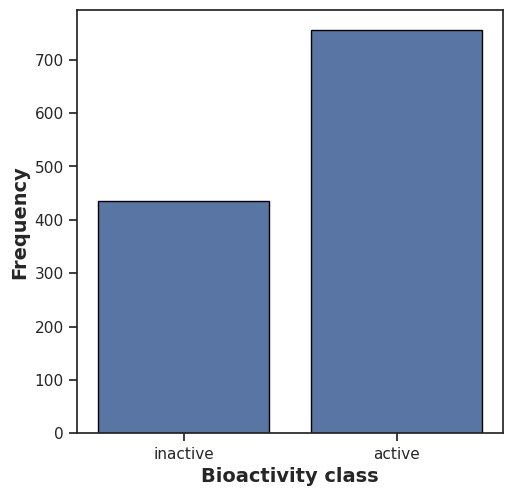

In [90]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

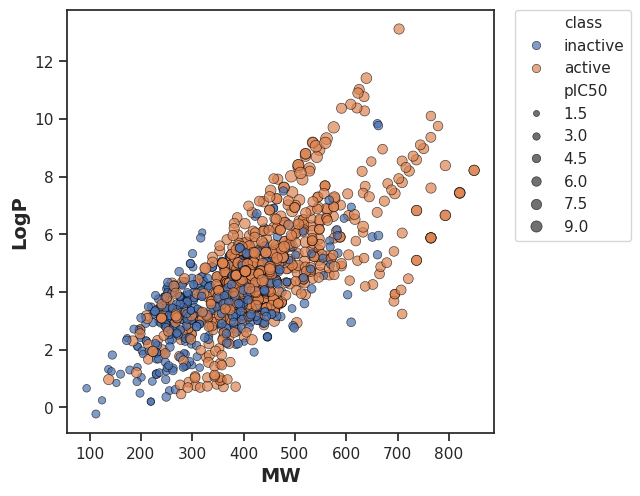

In [91]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

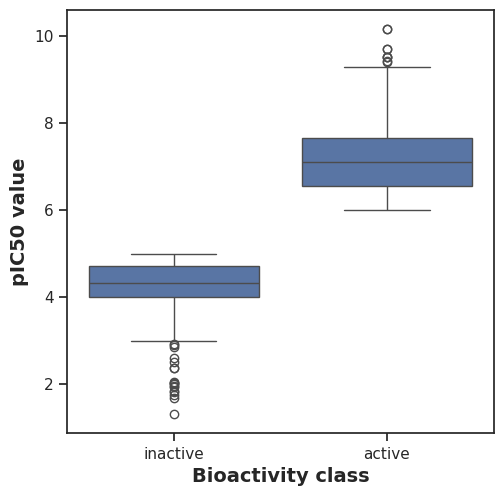

In [92]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [93]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'class']
  df = df_2class[selection]
  active = df[df['class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'class']
  df = df_2class[selection]
  inactive = df[df['class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'
  
  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [94]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,328860.0,4.854632e-182,0.05,Different distribution (reject H0)


#### **MW**

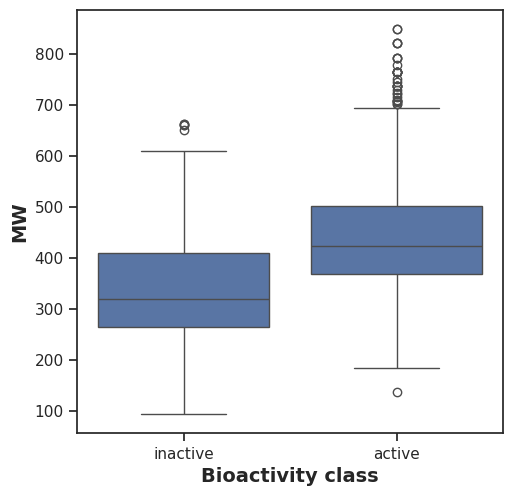

In [95]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [96]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,247075.5,2.172504e-47,0.05,Different distribution (reject H0)


#### **LogP**

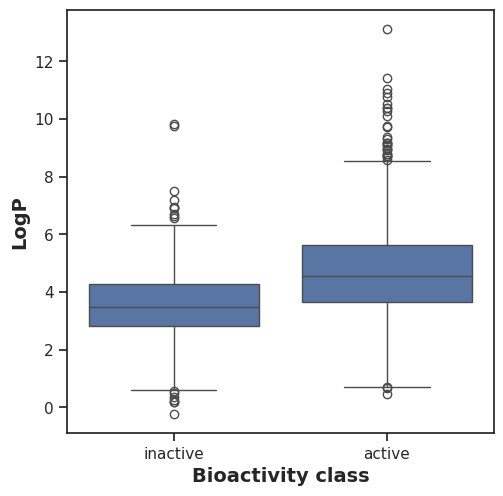

In [97]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [98]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,234607.0,1.184298e-34,0.05,Different distribution (reject H0)


#### **NumHDonors**

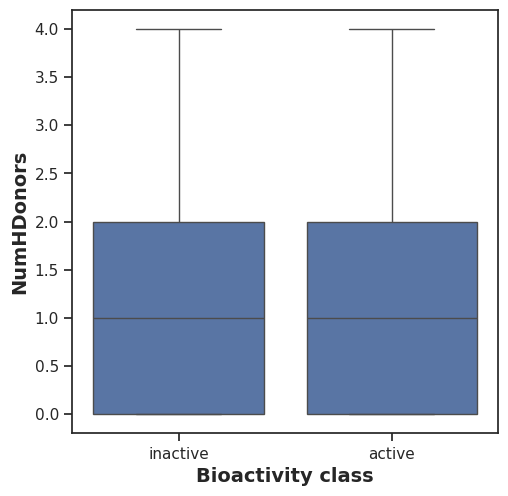

In [99]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [100]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,176550.0,0.025343,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

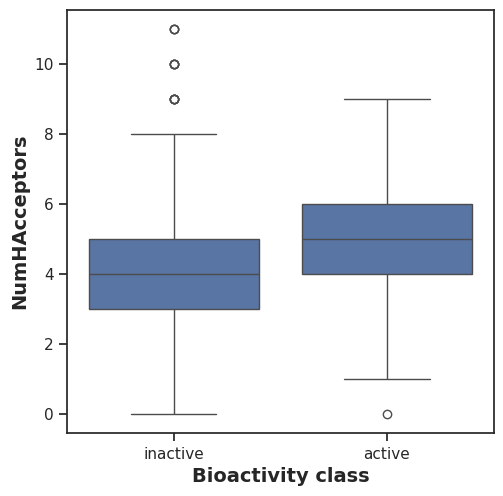

In [101]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [102]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,208069.5,8.833068e-15,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

All of the 4 Lipinski's descriptors exhibited ***statistically significant difference*** between the **actives** and **inactives**.

## **Zip files**

In [103]:
! zip -r results.zip . -i *.csv *.pdf -x "acetylcholinesterase_0[1-2]*" 

  adding: acetylcholinesterase_03_bioactivity_data_curated.csv (deflated 83%)
  adding: acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv (deflated 77%)
  adding: acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv (deflated 77%)
  adding: acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv (deflated 96%)
  adding: acetylcholinesterase_07_bioactivity_data_2class_pIC50_pubchem_fp.csv (deflated 96%)
  adding: plot_bioactivity_class.pdf (deflated 38%)
  adding: plot_MW_vs_LogP.pdf (deflated 3%)
  adding: plot_ic50.pdf (deflated 37%)
  adding: mannwhitneyu_pIC50.csv (deflated 10%)
  adding: plot_MW.pdf (deflated 38%)
  adding: mannwhitneyu_MW.csv (deflated 9%)
  adding: plot_LogP.pdf (deflated 38%)
  adding: mannwhitneyu_LogP.csv (deflated 8%)
  adding: plot_NumHDonors.pdf (deflated 38%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 10%)
  adding: plot_NumHAcceptors.pdf (deflated 37%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
